# `NescienceRegressor` demo

This notebook showcases the new `NescienceRegressor` class for the revised `mnplib` architecture.

The regressor implements **minimum-nescience model selection**:

```python
fit candidate model on (X, y)
extract explicit artifacts:
    subset, predictions, model_string
compute nescience
select the candidate with minimum nescience
```

The class does **not** use a train/test split or cross-validation. The theory evaluates the model with respect to the available effective representation `(X, y)`. Excessive complexity is penalized internally through the nescience components, especially `surfeit` and `surplus`.

This demo covers:

- default candidate search;
- custom candidate lists;
- result tables;
- component plots;
- explanations;
- canonical model-string inspection;
- weight sensitivity;
- DataFrame feature-name preservation;
- strict unsupported-model behavior.


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

from mnplib.regressor import NescienceRegressor

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Helper functions

These helpers are only for notebook display. They are not part of the library.


In [3]:
def plot_nescience(df, title):
    """Plot scalar nescience for candidate models."""
    df.set_index("candidate")["nescience"].plot(kind="bar", figsize=(11, 4))
    plt.ylabel("Nescience")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_components(df, title):
    """Plot the four nescience components for candidate models."""
    component_cols = ["deficiency", "surplus", "inaccuracy", "surfeit"]
    df.set_index("candidate")[component_cols].plot(kind="bar", figsize=(12, 5))
    plt.ylabel("Component value")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def print_section(title):
    """Print a visible separator."""
    print("\n" + title)
    print("=" * len(title))

## 3. Build a synthetic regression problem

The dataset has eight input features, but only three are informative. This is useful for seeing how different candidate models trade off accuracy, feature use, and description length.


In [4]:
X, y = make_regression(
    n_samples=700,
    n_features=8,
    n_informative=3,
    noise=15.0,
    random_state=42,
)

feature_names = [f"x{i}" for i in range(X.shape[1])]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (700, 8)
y shape: (700,)


## 4. Fit the default `NescienceRegressor`

The default candidate set currently includes:

- `LinearRegression`
- several `Ridge` models;
- several `Lasso` models;
- several `ElasticNet` models;
- several `DecisionTreeRegressor` models.

All candidates are evaluated on the same representation `(X, y)`.


In [5]:
reg = NescienceRegressor(
    n_bins="auto",
    random_state=42,
    verbose=1,
)

reg.fit(X, y)

linear_regression_prefix_1: nescience=0.639151, estimator_score=0.699405
linear_regression_prefix_2: nescience=0.647052, estimator_score=0.745089
linear_regression_prefix_3: nescience=0.656028, estimator_score=0.745548
linear_regression_prefix_4: nescience=0.666387, estimator_score=0.752079
linear_regression_prefix_5: nescience=0.664357, estimator_score=0.752174
linear_regression_prefix_6: nescience=0.671627, estimator_score=0.752929
linear_regression_prefix_7: nescience=0.672376, estimator_score=0.752935
linear_regression_prefix_8: nescience=0.675406, estimator_score=0.753167
decision_tree_regressor_ccp_0_alpha_0: nescience=0.721527, estimator_score=1.000000
decision_tree_regressor_ccp_1_alpha_5.74588e-08: nescience=0.721502, estimator_score=1.000000
decision_tree_regressor_ccp_2_alpha_2.50851e-07: nescience=0.721479, estimator_score=1.000000
decision_tree_regressor_ccp_3_alpha_1.25847e-06: nescience=0.721452, estimator_score=1.000000
decision_tree_regressor_ccp_4_alpha_2.06718e-06: n

,candidates,None
,X_type,'numeric'
,aggregation,'euclidean'
,n_bins,'auto'
,threshold_fraction,0.01
,surplus_penalty,1.0
,zlib_level,9
,zlib_overhead,6
,random_state,42
,alpha_tol,1e-12
,n_jobs,None


## 5. Selected model and main diagnostics

In [6]:
print("Best candidate:", reg.best_candidate_name_)
print("Selected estimator:", type(reg.get_model()).__name__)
print("Best nescience:", reg.nescience_score())
print("Native estimator score on full data:", reg.score(X, y))

print("\nComponents:")
for name, value in reg.components().items():
    print(f"{name:>10}: {value:.6f}")

Best candidate: linear_regression_prefix_1
Selected estimator: SelectedFeaturesEstimator
Best nescience: 0.6391514527652328
Native estimator score on full data: 0.6994053023655584

Components:
deficiency: 0.730681
   surplus: 0.741675
inaccuracy: 0.741675
   surfeit: 0.000000


## 6. Candidate comparison table

`results_dataframe()` gives a compact table with the selected model first because rows are sorted by ascending nescience.


In [7]:
results = reg.results_dataframe()
results

,candidate,candidate_source,family,model_family,model_type,searched_hyperparameters,nescience,native_estimator_score,estimator_score,selected_features,n_features_in_use,n_features_used,description_length,model_description_length,support_level,deficiency,surplus,inaccuracy,surfeit,n_outputs,n_nonzero_coefficients,task,serializer,n_features_in,feature_names,feature_reference_map,selected_feature_names,adapter_subset,selected_feature_indices,feature_order,selection_path_length,native_score,n_nodes,n_leaves,max_depth,ccp_alpha,alpha_tol,n_jobs,C,epsilon,loss,dual,max_iter,tol,converged,hidden_layer_sizes,activation,output_activation,n_layers,n_parameters,n_nonzero_parameters,n_iter,input_feature_indices,used_input_feature_indices,used_input_feature_names,model_string_prefix,move,n_hidden_layers,n_hidden_units,solver,alpha,scaler
0,linear_regression_prefix_1,internal,linear_regression,linear_regression,LinearRegression,{},0.639151,0.699405,0.699405,[2],1,1,43,43,None,0.730681,0.741675,0.741675,0.000000,1.0,1.0,regression,linear_model,1,[x2],{'X2': 'x2'},[x2],[0],[2],"[2, 4, 6, 1, 7, 0, 5, 3]",1.0,0.699405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,linear_regression_prefix_2,internal,linear_regression,linear_regression,LinearRegression,{},0.647052,0.745089,0.745089,"[2, 4]",2,2,61,61,None,0.689774,0.829875,0.709583,0.081967,1.0,2.0,regression,linear_model,2,"[x2, x4]","{'X2': 'x2', 'X4': 'x4'}","[x2, x4]","[0, 1]","[2, 4]","[2, 4, 6, 1, 7, 0, 5, 3]",1.0,0.745089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,linear_regression_prefix_3,internal,linear_regression,linear_regression,LinearRegression,{},0.656028,0.745548,0.745548,"[2, 4, 6]",3,3,79,79,None,0.663470,0.863452,0.710172,0.177215,1.0,3.0,regression,linear_model,3,"[x2, x4, x6]","{'X2': 'x2', 'X4': 'x4', 'X6': 'x6'}","[x2, x4, x6]","[0, 1, 2]","[2, 4, 6]","[2, 4, 6, 1, 7, 0, 5, 3]",1.0,0.745548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,linear_svr_C_0.1_epsilon_0,internal,linear_svr,linear_svr,LinearSVR,"{'C': 0.1, 'epsilon': 0.0, 'max_iter': 5000, '...",0.660269,0.708586,0.708586,"[0, 1, 2, 3, 4, 5, 6, 7]",8,8,151,151,None,0.587127,0.912070,0.705024,0.264901,NaN,8.0,regression,linear_svm,8,"[x0, x1, x2, x3, x4, x5, x6, x7]","{'X0': 'x0', 'X1': 'x1', 'X2': 'x2', 'X3': 'x3...","[x0, x1, x2, x3, x4, x5, x6, x7]",NaN,"[0, 1, 2, 3, 4, 5, 6, 7]",NaN,NaN,0.708586,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0.0,epsilon_insensitive,auto,5000.0,0.0001,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,linear_svr_C_1_epsilon_0,internal,linear_svr,linear_svr,LinearSVR,"{'C': 1.0, 'epsilon': 0.0, 'max_iter': 5000, '...",0.661079,0.751127,0.751127,"[0, 1, 2, 3, 4, 5, 6, 7]",8,8,151,151,None,0.587127,0.912070,0.708054,0.264901,NaN,8.0,regression,linear_svm,8,"[x0, x1, x2, x3, x4, x5, x6, x7]","{'X0': 'x0', 'X1': 'x1', 'X2': 'x2', 'X3': 'x3...","[x0, x1, x2, x3, x4, x5, x6, x7]",NaN,"[0, 1, 2, 3, 4, 5, 6, 7]",NaN,NaN,0.751127,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,epsilon_insensitive,auto,5000.0,0.0001,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,decision_tree_regressor_ccp_637_alpha_2.54406,internal,decision_tree_regressor,decision_tree_regressor,DecisionTreeRegressor,{'ccp_alpha': 2.544057642710161},0.742255,0.803848,0.803848,"[0, 1, 2, 3, 4, 7]",6,6,1474,1474,None,0.613590,0.903775,0.660457,0.757802,NaN,NaN,regression,base,8,"[x0, x1, x2, x3, x4, x5, x6, x7]","{'X0': 'x0', 'X1': 'x1', 'X2': 'x2', 'X3': 'x3...","[x0, x1, x2, x3, x4, x7]",NaN,NaN,NaN,NaN,0.803848,57.0,29.0,7.0,2.544

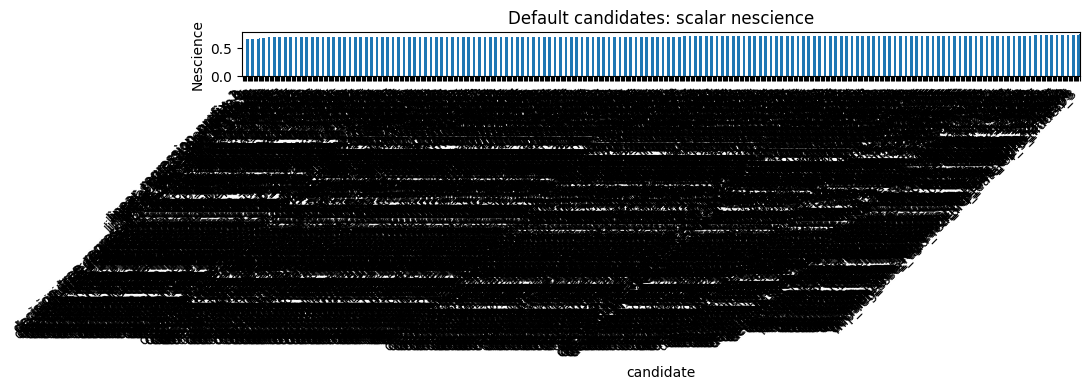

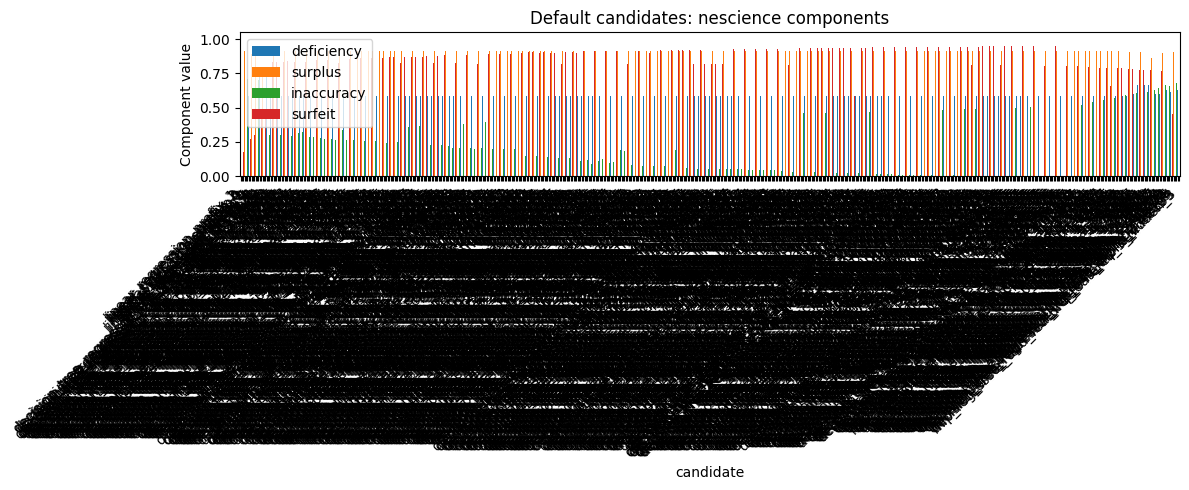

In [8]:
plot_nescience(results, "Default candidates: scalar nescience")
plot_components(results, "Default candidates: nescience components")

## 7. Native predictive score versus nescience

The native estimator score for regressors is usually \(R^2\), while nescience is a different objective. A candidate may score very well predictively but still have higher nescience because it uses an unnecessarily complex or redundant description.


In [9]:
comparison = results[
    [
        "candidate",
        "model_type",
        "estimator_score",
        "nescience",
        "inaccuracy",
        "surfeit",
        "n_features_in_use",
        "description_length",
    ]
].copy()

comparison.sort_values("estimator_score", ascending=False)

,candidate,model_type,estimator_score,nescience,inaccuracy,surfeit,n_features_in_use,description_length
607,decision_tree_regressor_ccp_0_alpha_0,DecisionTreeRegressor,1.000000,0.721527,0.000000,0.951743,8,50355
606,decision_tree_regressor_ccp_1_alpha_5.74588e-08,DecisionTreeRegressor,1.000000,0.721502,0.000000,0.951668,8,50277
605,decision_tree_regressor_ccp_2_alpha_2.50851e-07,DecisionTreeRegressor,1.000000,0.721479,0.000000,0.951598,8,50204
604,decision_tree_regressor_ccp_3_alpha_1.25847e-06,DecisionTreeRegressor,1.000000,0.721452,0.000000,0.951515,8,50118
603,decision_tree_regressor_ccp_4_alpha_2.06718e-06,DecisionTreeRegressor,1.000000,0.721427,0.000000,0.951439,8,50039
...,...,...,...,...,...,...,...,...
623,mlp_regressor_add_layer_features_2_hidden_3x3,MLPRegressor,0.047974,0.725407,0.843905,0.477707,2,628
18,mlp_regressor_initial_features_2_hidden_3,MLPRegressor,0.039258,0.693885,0.759291,0.430000,2,500
682,mlp_regressor_add_feature_features_3_hidden_3,MLPRegressor,0.009855,0.751362,0.932918,0.449558,3,565
677,mlp_regressor_add_unit_features_2_hidden_4,MLPRegressor,0.000056,0.742218,0.914053,0.451197,2,543


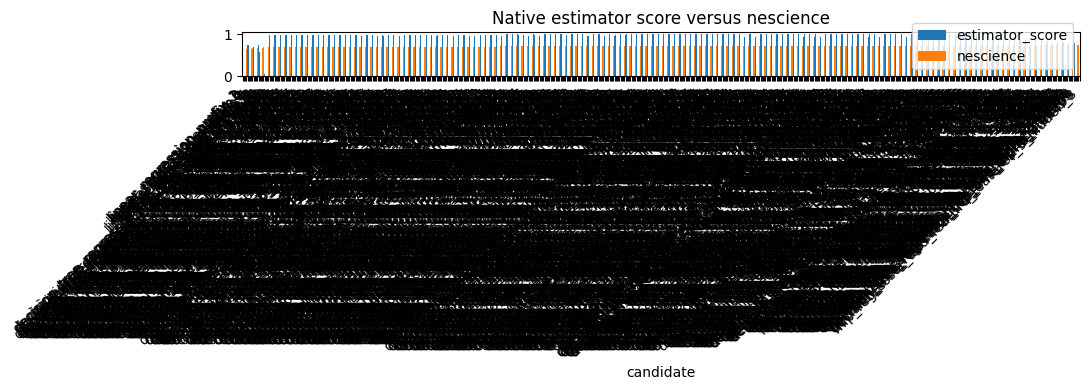

In [10]:
comparison.set_index("candidate")[["estimator_score", "nescience"]].plot(
    kind="bar",
    figsize=(11, 4),
)
plt.title("Native estimator score versus nescience")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Explanation of the selected model

`explain()` delegates to the fitted `Nescience` object and adds the selected candidate name plus adapter metadata.


In [11]:
explanation = reg.explain()

print("Candidate:", explanation["candidate_name"])
print("Model type:", explanation["model_type"])
print("Dominant component:", explanation["dominant_component"])
print("Profile:", explanation["profile"])
print("Recommendation:", explanation["recommendation"])

print("\nModel metadata:")
for key, value in explanation["model_metadata"].items():
    print(f"{key}: {value}")

Candidate: linear_regression_prefix_1
Model type: LinearRegression
Dominant component: surplus
Profile: poor_input_representation
Recommendation: Dominant source of nescience: surplus (0.7417). Reduce target-irrelevant input information: apply feature selection, increase the surplus penalty, remove noisy variables, or simplify the representation used by the model.

Model metadata:
n_outputs: 1
n_nonzero_coefficients: 1
task: regression
serializer: linear_model
n_features_in: 1
n_features_in_use: 1
feature_names: ['x2']
feature_reference_map: {'X2': 'x2'}
selected_feature_names: ['x2']
adapter_subset: [0]
selected_feature_indices: [2]


## 9. Inspect the canonical model string

The selected model is serialized into the canonical model-description schema used by the new scikit-learn adapter layer.


In [12]:
model_string = reg.model_string()

print(model_string[:2500])
print("\nDescription length in bytes:", len(model_string.encode("utf-8")))

 y = -7.89e-01
 y += 2.70e+01*X2
 return y


Description length in bytes: 43


## 10. Custom candidate set

For demos or controlled experiments, it is often better to pass an explicit candidate list.


In [14]:
custom_candidates = [
    ("linear", LinearRegression()),
    ("ridge_1", Ridge(alpha=1.0)),
    ("lasso_001", Lasso(alpha=0.01, max_iter=10000)),
    ("elastic_net_001", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)),
    ("tree_depth_2", DecisionTreeRegressor(max_depth=2, random_state=42)),
    ("tree_depth_4", DecisionTreeRegressor(max_depth=4, random_state=42)),
]

custom_reg = NescienceRegressor(
    n_bins="auto",
    random_state=42
)

custom_reg.fit(X, y)

custom_results = custom_reg.results_dataframe()
custom_results

,candidate,candidate_source,family,model_family,model_type,searched_hyperparameters,nescience,native_estimator_score,estimator_score,selected_features,n_features_in_use,n_features_used,description_length,model_description_length,support_level,deficiency,surplus,inaccuracy,surfeit,n_outputs,n_nonzero_coefficients,task,serializer,n_features_in,feature_names,feature_reference_map,selected_feature_names,adapter_subset,selected_feature_indices,feature_order,selection_path_length,native_score,n_nodes,n_leaves,max_depth,ccp_alpha,alpha_tol,n_jobs,C,epsilon,loss,dual,max_iter,tol,converged,hidden_layer_sizes,activation,output_activation,n_layers,n_parameters,n_nonzero_parameters,n_iter,input_feature_indices,used_input_feature_indices,used_input_feature_names,model_string_prefix,move,n_hidden_layers,n_hidden_units,solver,alpha,scaler
0,linear_regression_prefix_1,internal,linear_regression,linear_regression,LinearRegression,{},0.639151,0.699405,0.699405,[2],1,1,43,43,None,0.730681,0.741675,0.741675,0.000000,1.0,1.0,regression,linear_model,1,[x2],{'X2': 'x2'},[x2],[0],[2],"[2, 4, 6, 1, 7, 0, 5, 3]",1.0,0.699405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,linear_regression_prefix_2,internal,linear_regression,linear_regression,LinearRegression,{},0.647052,0.745089,0.745089,"[2, 4]",2,2,61,61,None,0.689774,0.829875,0.709583,0.081967,1.0,2.0,regression,linear_model,2,"[x2, x4]","{'X2': 'x2', 'X4': 'x4'}","[x2, x4]","[0, 1]","[2, 4]","[2, 4, 6, 1, 7, 0, 5, 3]",1.0,0.745089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,linear_regression_prefix_3,internal,linear_regression,linear_regression,LinearRegression,{},0.656028,0.745548,0.745548,"[2, 4, 6]",3,3,79,79,None,0.663470,0.863452,0.710172,0.177215,1.0,3.0,regression,linear_model,3,"[x2, x4, x6]","{'X2': 'x2', 'X4': 'x4', 'X6': 'x6'}","[x2, x4, x6]","[0, 1, 2]","[2, 4, 6]","[2, 4, 6, 1, 7, 0, 5, 3]",1.0,0.745548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,linear_svr_C_0.1_epsilon_0,internal,linear_svr,linear_svr,LinearSVR,"{'C': 0.1, 'epsilon': 0.0, 'max_iter': 5000, '...",0.660269,0.708586,0.708586,"[0, 1, 2, 3, 4, 5, 6, 7]",8,8,151,151,None,0.587127,0.912070,0.705024,0.264901,NaN,8.0,regression,linear_svm,8,"[x0, x1, x2, x3, x4, x5, x6, x7]","{'X0': 'x0', 'X1': 'x1', 'X2': 'x2', 'X3': 'x3...","[x0, x1, x2, x3, x4, x5, x6, x7]",NaN,"[0, 1, 2, 3, 4, 5, 6, 7]",NaN,NaN,0.708586,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0.0,epsilon_insensitive,auto,5000.0,0.0001,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,linear_svr_C_1_epsilon_0,internal,linear_svr,linear_svr,LinearSVR,"{'C': 1.0, 'epsilon': 0.0, 'max_iter': 5000, '...",0.661079,0.751127,0.751127,"[0, 1, 2, 3, 4, 5, 6, 7]",8,8,151,151,None,0.587127,0.912070,0.708054,0.264901,NaN,8.0,regression,linear_svm,8,"[x0, x1, x2, x3, x4, x5, x6, x7]","{'X0': 'x0', 'X1': 'x1', 'X2': 'x2', 'X3': 'x3...","[x0, x1, x2, x3, x4, x5, x6, x7]",NaN,"[0, 1, 2, 3, 4, 5, 6, 7]",NaN,NaN,0.751127,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,epsilon_insensitive,auto,5000.0,0.0001,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,decision_tree_regressor_ccp_637_alpha_2.54406,internal,decision_tree_regressor,decision_tree_regressor,DecisionTreeRegressor,{'ccp_alpha': 2.544057642710161},0.742255,0.803848,0.803848,"[0, 1, 2, 3, 4, 7]",6,6,1474,1474,None,0.613590,0.903775,0.660457,0.757802,NaN,NaN,regression,base,8,"[x0, x1, x2, x3, x4, x5, x6, x7]","{'X0': 'x0', 'X1': 'x1', 'X2': 'x2', 'X3': 'x3...","[x0, x1, x2, x3, x4, x7]",NaN,NaN,NaN,NaN,0.803848,57.0,29.0,7.0,2.544

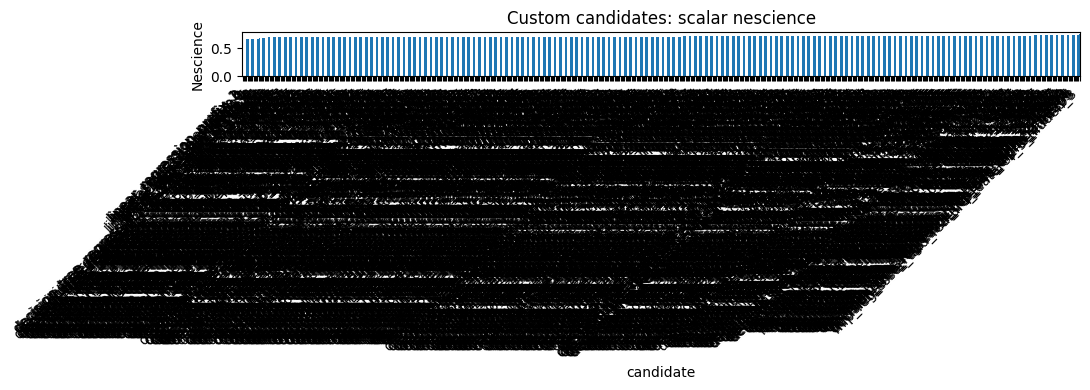

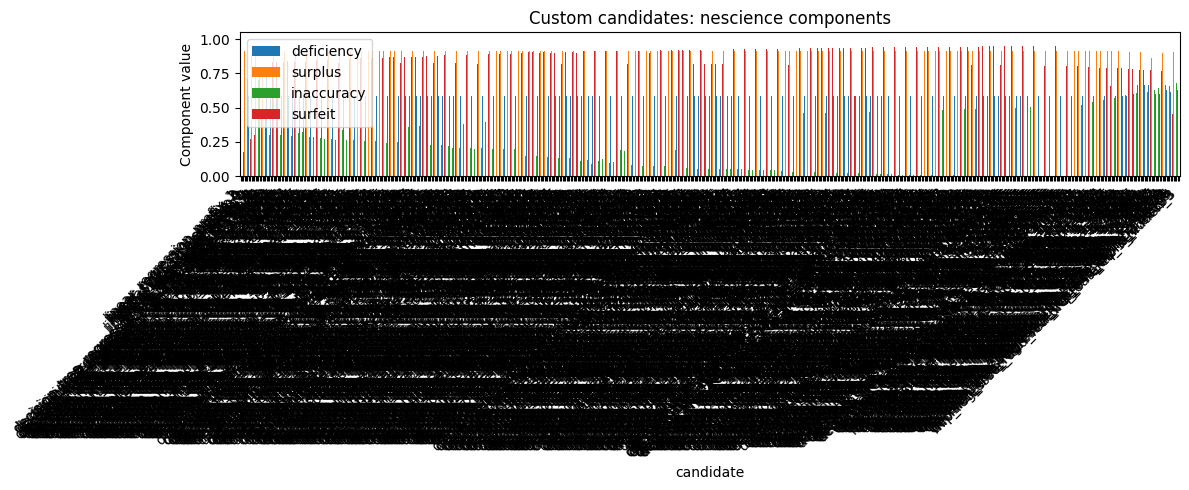

In [15]:
plot_nescience(custom_results, "Custom candidates: scalar nescience")
plot_components(custom_results, "Custom candidates: nescience components")

## 11. DataFrame feature names

If `X` is a pandas DataFrame, the canonical model strings preserve column names.


In [16]:
X_df = pd.DataFrame(X, columns=[f"feature_{j}" for j in range(X.shape[1])])

df_reg = NescienceRegressor(
    n_bins="auto",
    random_state=42
)

df_reg.fit(X_df, y)

print("Feature names stored in the regressor:")
print(list(df_reg.feature_names_in_))

print("\nCanonical model string excerpt:")
print(df_reg.model_string()[:1500])

Feature names stored in the regressor:
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7']

Canonical model string excerpt:
 y = -7.89e-01
 y += 2.70e+01*X2
 return y



## 12. Summary

The new `NescienceRegressor` is a small model-selection orchestrator:

```python
NescienceRegressor
    -> fits candidate regressors on (X, y)
    -> extracts canonical artifacts with mnplib.models
    -> computes nescience with Nescience
    -> selects the candidate with minimum nescience
```

Its most useful outputs are:

```python
reg.best_candidate_name_
reg.best_nescience_
reg.components()
reg.explain()
reg.results_dataframe()
reg.model_string()
```

This keeps the model-selection logic separate from the metric classes and from the model serializers.
